# ADIM 3 — RQ1: Dengeleme yöntemleri karşılaştırması

Taşınan model **LightGBM** (tek aile), Adım 2'deki `best_params_<set>` ile.
5 **etiketli** set **bağımsız** işlenir; asla birleştirilmez. Holdout girmez.

Koşullar: **Baseline** (doğal, eşik 0.5) · **Class-weight** (scale_pos_weight) ·
**SMOTENC/SMOTE** · **ADASYN** · **Eşik kaydırma** (max-F1; istatistiksel, kâr değil).

**Sızıntı kuralı:** tüm resampling / class-weight / eşik seçimi yalnız fold-içi
eğitimde (imblearn Pipeline: [prep] -> [resample] -> [encode] -> [LightGBM]).
Validation katı doğal bırakılır. Stratified 5-kat (seed=42), birincil skor PR-AUC.
**KAZANAN SEÇİLMEZ** — trade-off raporlanır. Ağır mantık `src/` fonksiyonlarında.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml bulunamadı")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import config as cfg
from src import imbalance as imb
from src import plotstyle as ps
from src import strings_tr as S

np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Veri yükleme

In [2]:
veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
for k, d in veriler.items():
    yaz(f"{k:11s} {d.shape}  churn=%{100*d['churn'].mean():.1f}")
yaz(S.MSG3["adasyn_not"])

telco       (7043, 20)  churn=%26.5
cell2cell   (51047, 57)  churn=%28.8
ecommerce   (3941, 11)  churn=%17.1
iranian     (3150, 14)  churn=%15.7
bank        (10000, 11)  churn=%20.4
NOT: ADASYN encode edilmiş matriste çalışır; one-hot kategorik kolonlar için kesirli değerler üretir (sentetik örnekler 0/1 dışına çıkar) — Methods/limitations'a yazılacak.


## 2. RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul)
**(En uzun adım.)** Her set için 4 model-koşulu (baseline/class-weight/SMOTE/ADASYN)
fit edilir; eşik kaydırma baseline modelini yeniden kullanır.

In [3]:
yaz(S.MSG["bolum"].format(ad="RQ1 DENGELEME"))
tum = {}
for k in cfg.DATASETS:
    t = time.time()
    tum[k] = imb.calistir_set_rq1(k, veriler[k], cfg.SEED)
    yaz(S.MSG3["set_basla"].format(set=k, n=len(imb.KOSULLAR)) + f" ({time.time()-t:.0f}s)")
    for ko in imb.KOSULLAR:
        pf = tum[k][ko]["perfold"]
        yaz(S.MSG3["kosul"].format(set=k, yontem=S.KOSUL_AD[ko],
            pr=f"{np.mean(pf['PR-AUC']):.3f}", rec=f"{np.mean(pf['recall']):.3f}",
            pre=f"{np.mean(pf['precision']):.3f}", ece=f"{np.mean(pf['ECE']):.3f}",
            esik=f"{np.mean(pf['esik']):.3f}"))

===== RQ1 DENGELEME =====


telco: RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul) (17s)
  telco / Baseline (doğal): PR-AUC=0.664 recall=0.518 precision=0.666 ECE=0.022 eşik=0.500
  telco / Class-weight: PR-AUC=0.664 recall=0.780 precision=0.528 ECE=0.131 eşik=0.500
  telco / SMOTENC/SMOTE: PR-AUC=0.638 recall=0.685 precision=0.569 ECE=0.084 eşik=0.500
  telco / ADASYN: PR-AUC=0.652 recall=0.577 precision=0.619 ECE=0.036 eşik=0.500
  telco / Eşik kaydırma (max-F1): PR-AUC=0.664 recall=0.741 precision=0.571 ECE=0.022 eşik=0.328


cell2cell: RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul) (93s)
  cell2cell / Baseline (doğal): PR-AUC=0.466 recall=0.133 precision=0.600 ECE=0.009 eşik=0.500
  cell2cell / Class-weight: PR-AUC=0.464 recall=0.628 precision=0.409 ECE=0.177 eşik=0.500
  cell2cell / SMOTENC/SMOTE: PR-AUC=0.437 recall=0.187 precision=0.511 ECE=0.030 eşik=0.500
  cell2cell / ADASYN: PR-AUC=0.462 recall=0.133 precision=0.591 ECE=0.012 eşik=0.500
  cell2cell / Eşik kaydırma (max-F1): PR-AUC=0.466 recall=0.771 precision=0.376 ECE=0.009 eşik=0.245


ecommerce: RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul) (76s)
  ecommerce / Baseline (doğal): PR-AUC=0.908 recall=0.819 precision=0.882 ECE=0.039 eşik=0.500
  ecommerce / Class-weight: PR-AUC=0.906 recall=0.837 precision=0.852 ECE=0.042 eşik=0.500
  ecommerce / SMOTENC/SMOTE: PR-AUC=0.886 recall=0.828 precision=0.830 ECE=0.048 eşik=0.500
  ecommerce / ADASYN: PR-AUC=0.907 recall=0.828 precision=0.876 ECE=0.041 eşik=0.500
  ecommerce / Eşik kaydırma (max-F1): PR-AUC=0.908 recall=0.844 precision=0.868 ECE=0.039 eşik=0.367


iranian: RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul) (66s)
  iranian / Baseline (doğal): PR-AUC=0.958 recall=0.851 precision=0.893 ECE=0.018 eşik=0.500
  iranian / Class-weight: PR-AUC=0.954 recall=0.915 precision=0.853 ECE=0.019 eşik=0.500
  iranian / SMOTENC/SMOTE: PR-AUC=0.954 recall=0.923 precision=0.836 ECE=0.025 eşik=0.500
  iranian / ADASYN: PR-AUC=0.953 recall=0.887 precision=0.871 ECE=0.022 eşik=0.500
  iranian / Eşik kaydırma (max-F1): PR-AUC=0.958 recall=0.921 precision=0.878 ECE=0.018 eşik=0.321


bank: RQ1 dengeleme karşılaştırması (LightGBM sabit, 5 koşul) (17s)
  bank / Baseline (doğal): PR-AUC=0.706 recall=0.481 precision=0.760 ECE=0.020 eşik=0.500
  bank / Class-weight: PR-AUC=0.706 recall=0.743 precision=0.526 ECE=0.152 eşik=0.500
  bank / SMOTENC/SMOTE: PR-AUC=0.657 recall=0.683 precision=0.531 ECE=0.131 eşik=0.500
  bank / ADASYN: PR-AUC=0.698 recall=0.543 precision=0.701 ECE=0.035 eşik=0.500
  bank / Eşik kaydırma (max-F1): PR-AUC=0.706 recall=0.632 precision=0.642 ECE=0.020 eşik=0.328


## 3. Tablolar
`rq1_imbalance_comparison.csv` (set × yöntem; PR-AUC, ROC-AUC, recall, precision, F1,
ECE, Brier, eşik — mean ± std) ve `rq1_thresholds.csv`.

In [4]:
karsi = imb.tablo_karsilastirma(tum)
esikler = imb.tablo_esikler(tum)
yaz(S.MSG["bolum"].format(ad="RQ1 KARŞILAŞTIRMA (fold ort. ± std)"))
yaz(karsi.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "rq1_imbalance_comparison.csv"))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "rq1_thresholds.csv"))

===== RQ1 KARŞILAŞTIRMA (fold ort. ± std) =====
Veri Seti                 Yöntem          PR-AUC         ROC-AUC      Duyarlılık        Kesinlik              F1             ECE           Brier            Eşik
    telco       Baseline (doğal) 0.6635 ± 0.0223 0.8469 ± 0.0108 0.5179 ± 0.0353 0.6661 ± 0.0241 0.5825 ± 0.0303 0.0224 ± 0.0077 0.1345 ± 0.0045 0.5000 ± 0.0000
    telco           Class-weight 0.6639 ± 0.0233 0.8459 ± 0.0107 0.7801 ± 0.0179 0.5278 ± 0.0112 0.6295 ± 0.0123 0.1310 ± 0.0058 0.1584 ± 0.0047 0.5000 ± 0.0000
    telco          SMOTENC/SMOTE 0.6384 ± 0.0245 0.8395 ± 0.0104 0.6848 ± 0.0333 0.5695 ± 0.0109 0.6216 ± 0.0187 0.0838 ± 0.0066 0.1500 ± 0.0040 0.5000 ± 0.0000
    telco                 ADASYN 0.6524 ± 0.0266 0.8430 ± 0.0118 0.5773 ± 0.0302 0.6191 ± 0.0155 0.5973 ± 0.0225 0.0364 ± 0.0026 0.1381 ± 0.0049 0.5000 ± 0.0000
    telco Eşik kaydırma (max-F1) 0.6635 ± 0.0223 0.8469 ± 0.0108 0.7410 ± 0.0559 0.5714 ± 0.0385 0.6421 ± 0.0143 0.0224 ± 0.0077 0.1345 ± 0.0045 0.

## 4. Figürler
Her set için `outputs/figures/<set>/`: rq1_prauc_by_method, rq1_recall_precision,
rq1_calibration_by_method, rq1_pr_curve_operating.

===== FİGÜRLER =====


telco: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/telco


cell2cell: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/cell2cell


ecommerce: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/ecommerce


iranian: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/iranian


bank: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/bank


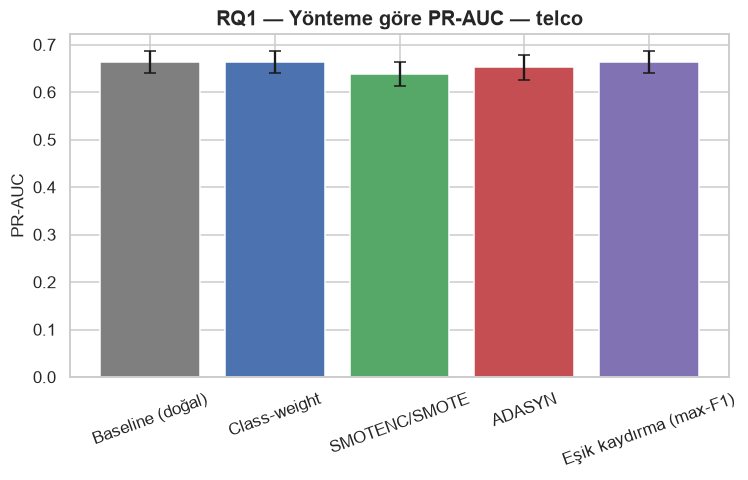

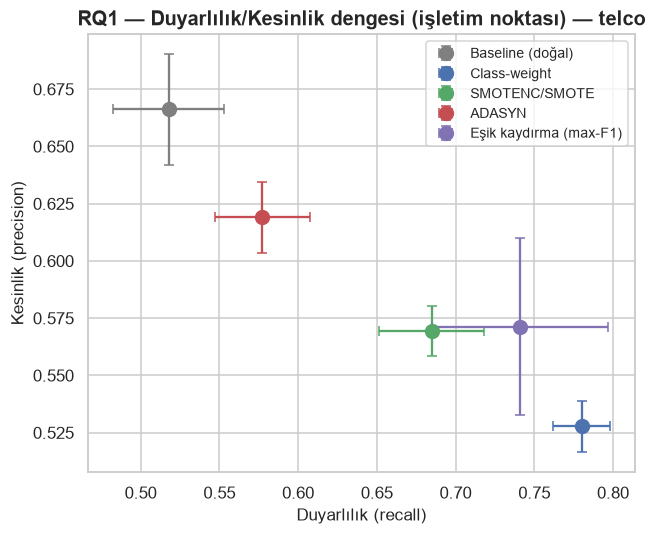

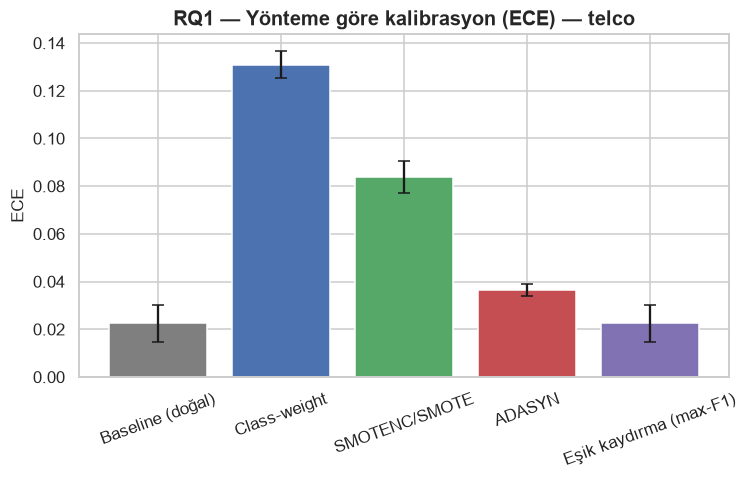

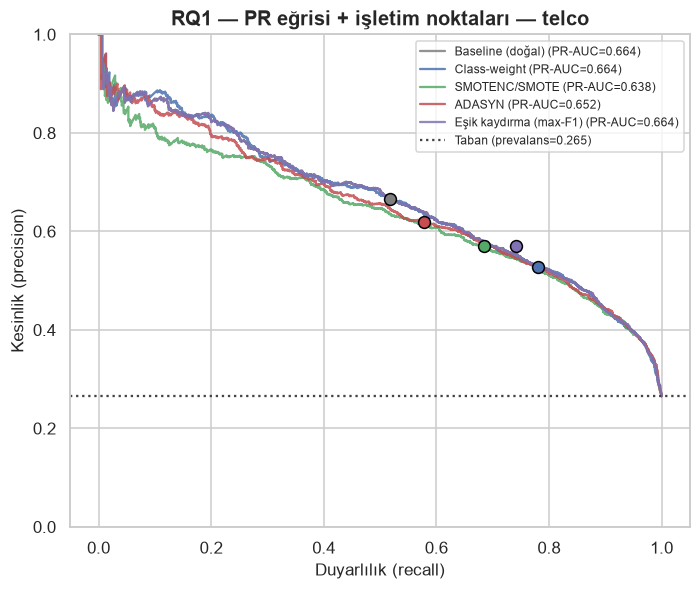

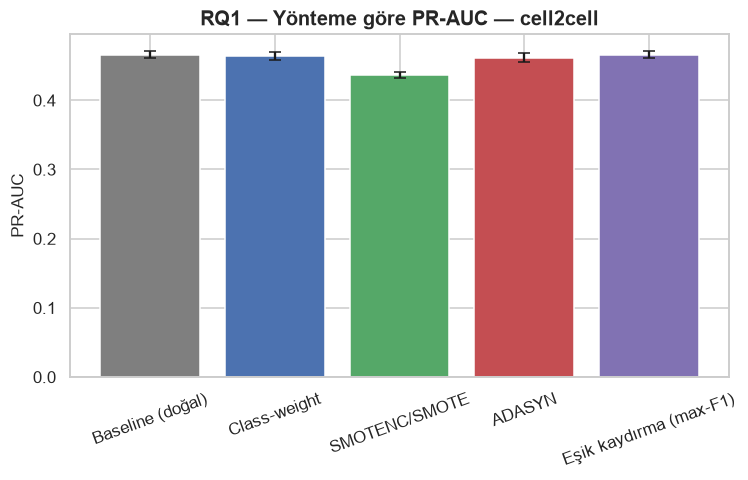

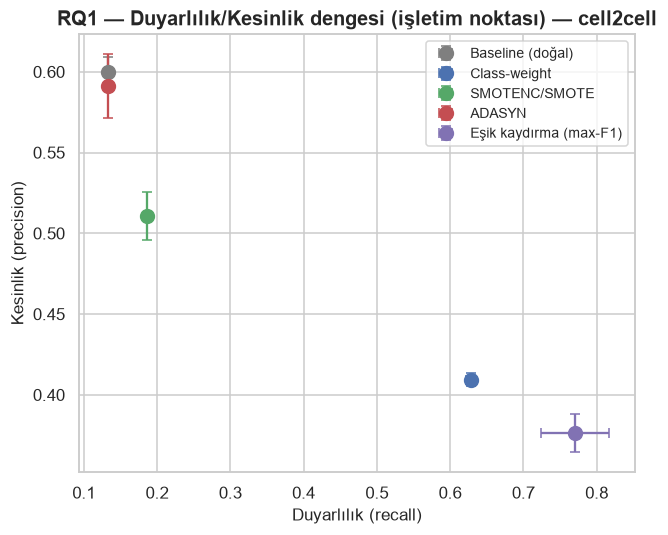

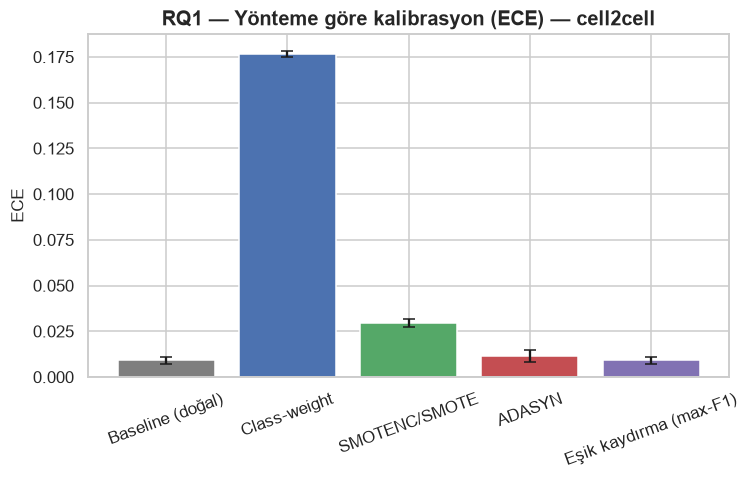

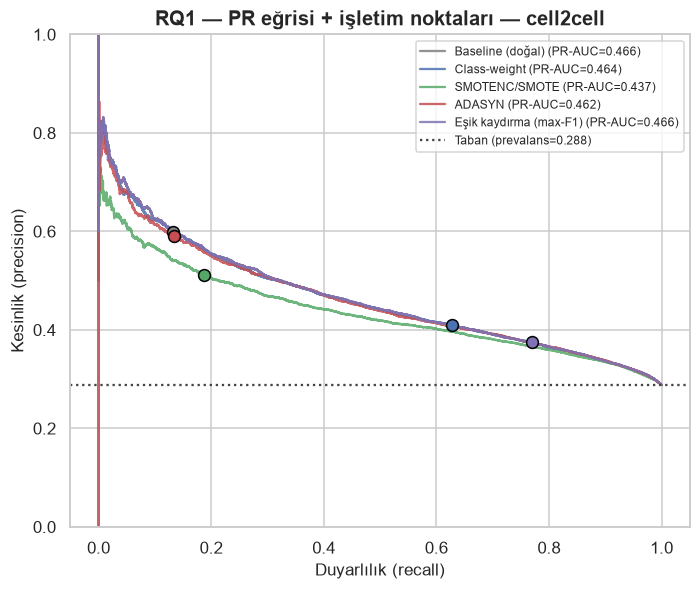

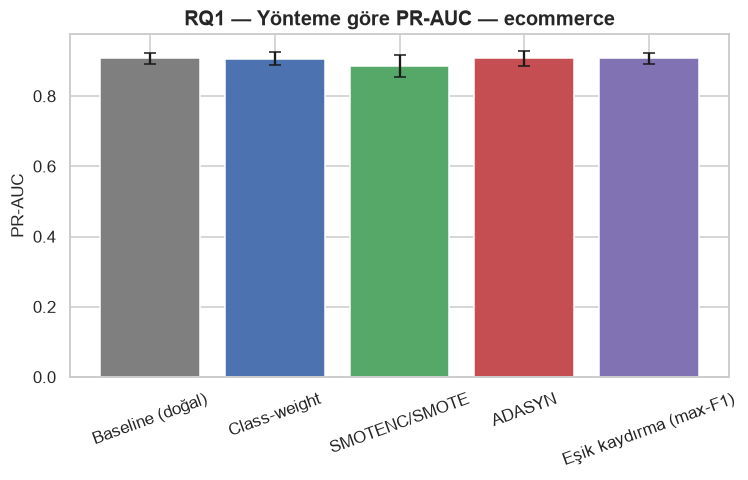

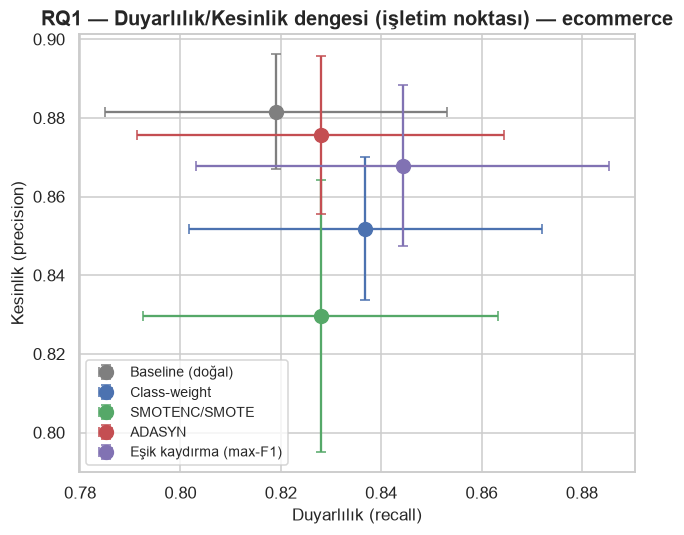

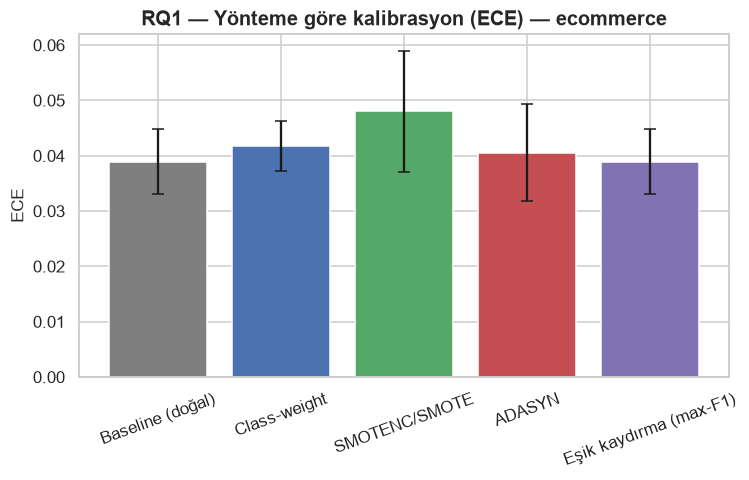

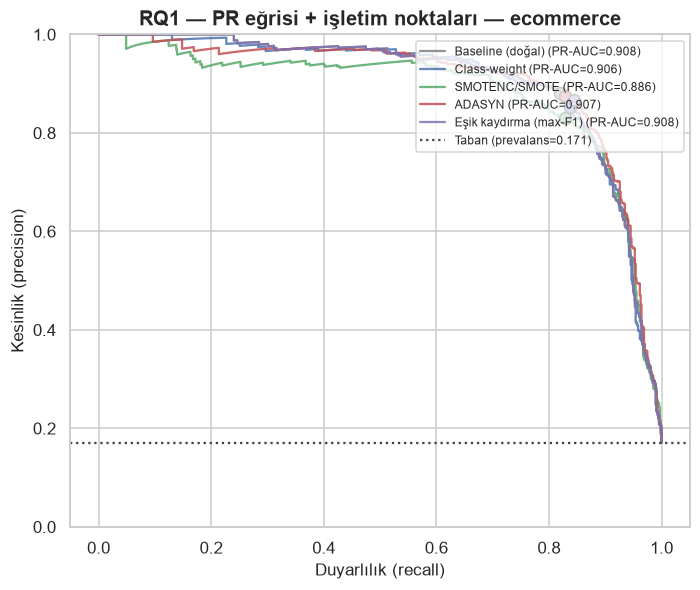

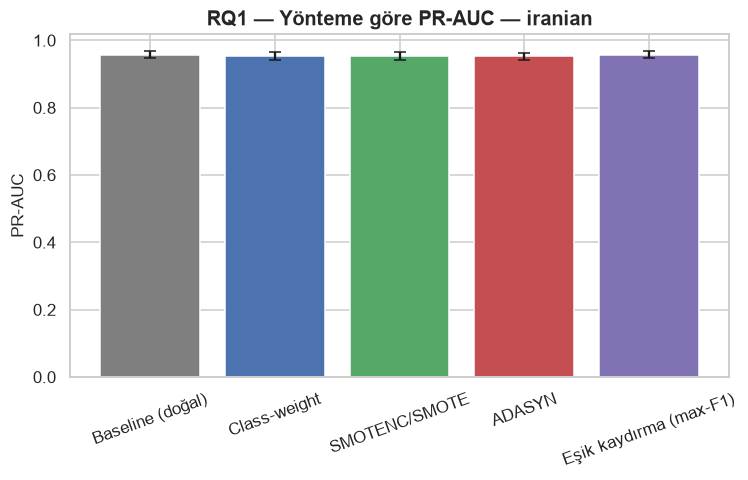

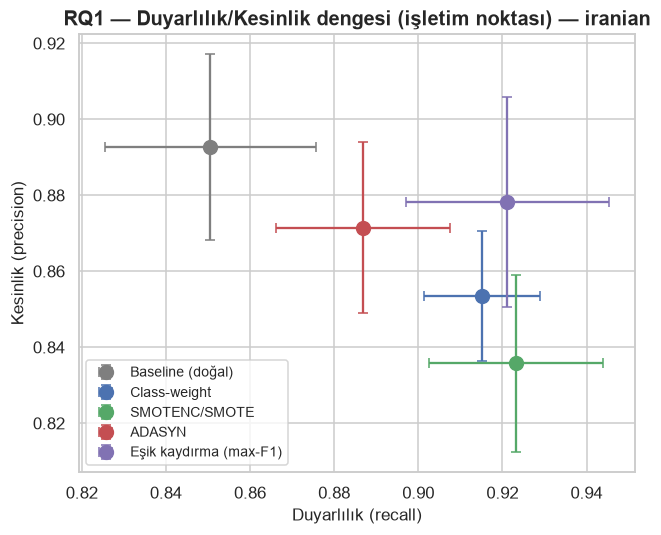

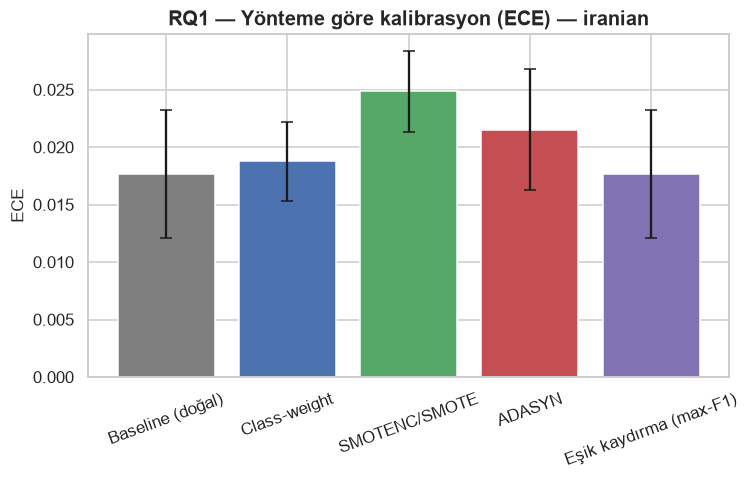

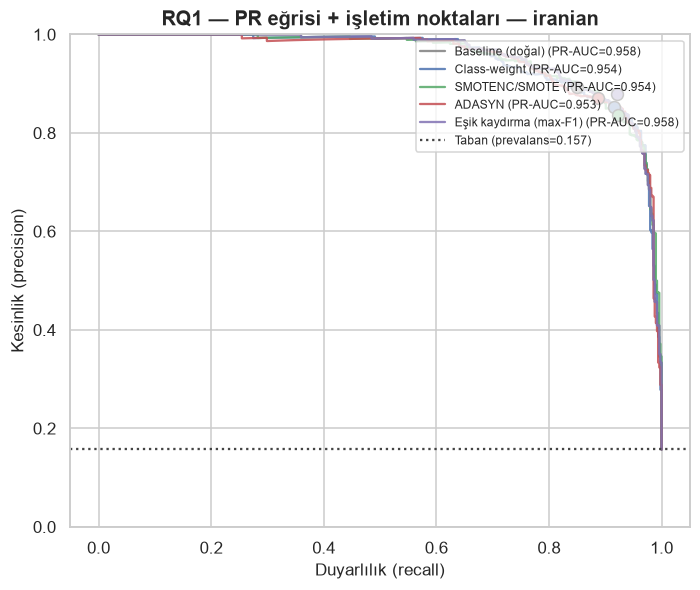

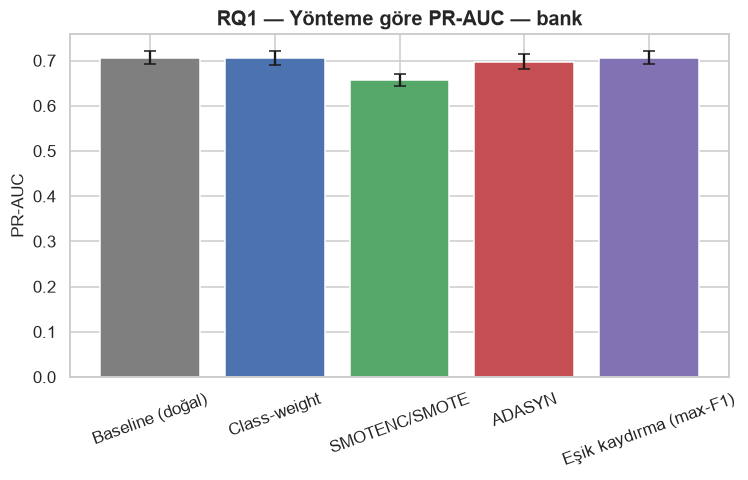

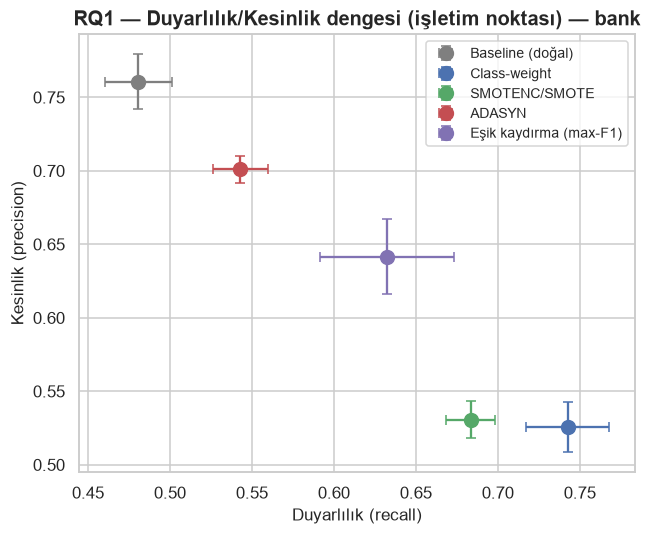

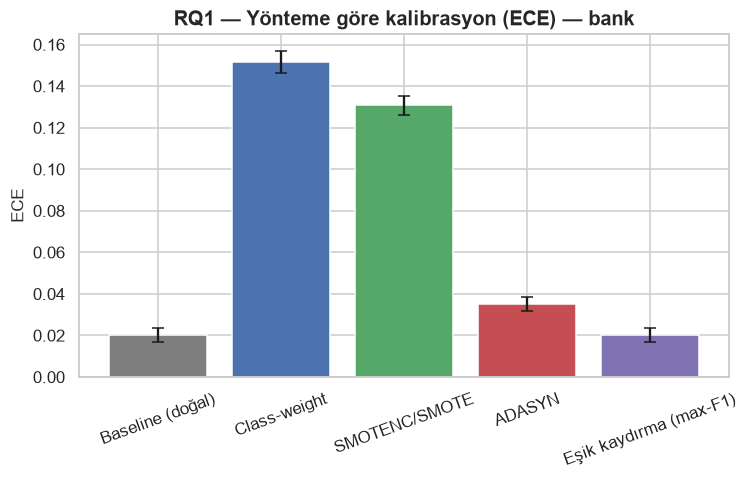

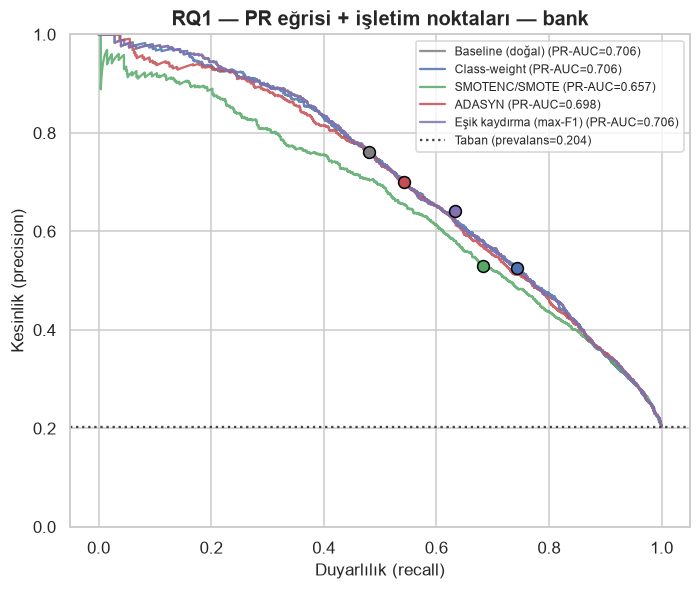

In [5]:
yaz(S.MSG["bolum"].format(ad="FİGÜRLER"))
for k in cfg.DATASETS:
    yollar = imb.figurler_set(k, tum[k], veriler[k]["churn"].to_numpy())
    yaz(f"{k}: {len(yollar)} figür -> {cfg.FIGURES / k}")

## 5. Özet — baseline'a göre değişim (Δ), trade-off, kalibrasyon, eşik
Karar/yorum kullanıcıda; burada yalnızca kanıt.

In [6]:
yaz(S.MSG["bolum"].format(ad="ÖZET — baseline'a göre"))


def ort(res, ko, m):
    return float(np.mean(res[ko]["perfold"][m]))


for k in cfg.DATASETS:
    res = tum[k]
    b_pr, b_rec, b_pre, b_f1, b_ece = (ort(res, "baseline", m) for m in ["PR-AUC", "recall", "precision", "F1", "ECE"])
    yaz(f"\n### {k}  (baseline: PR-AUC={b_pr:.3f} recall={b_rec:.3f} precision={b_pre:.3f} F1={b_f1:.3f} ECE={b_ece:.3f})")
    for ko in ["class_weight", "smote", "adasyn", "threshold"]:
        pr, rec, pre, f1, ece = (ort(res, ko, m) for m in ["PR-AUC", "recall", "precision", "F1", "ECE"])
        yaz(f"  {S.KOSUL_AD[ko]:24s} ΔPR-AUC={pr-b_pr:+.3f} | recall {b_rec:.3f}->{rec:.3f} "
            f"({rec-b_rec:+.3f}) | precision {b_pre:.3f}->{pre:.3f} ({pre-b_pre:+.3f}) | "
            f"F1 {f1-b_f1:+.3f} | ECE {ece-b_ece:+.3f}")

yaz("")
yaz(S.MSG3["bitti"])
_log = cfg.LOGS / "adim3_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== ÖZET — baseline'a göre =====

### telco  (baseline: PR-AUC=0.664 recall=0.518 precision=0.666 F1=0.582 ECE=0.022)
  Class-weight             ΔPR-AUC=+0.000 | recall 0.518->0.780 (+0.262) | precision 0.666->0.528 (-0.138) | F1 +0.047 | ECE +0.109
  SMOTENC/SMOTE            ΔPR-AUC=-0.025 | recall 0.518->0.685 (+0.167) | precision 0.666->0.569 (-0.097) | F1 +0.039 | ECE +0.061
  ADASYN                   ΔPR-AUC=-0.011 | recall 0.518->0.577 (+0.059) | precision 0.666->0.619 (-0.047) | F1 +0.015 | ECE +0.014
  Eşik kaydırma (max-F1)   ΔPR-AUC=+0.000 | recall 0.518->0.741 (+0.223) | precision 0.666->0.571 (-0.095) | F1 +0.060 | ECE +0.000

### cell2cell  (baseline: PR-AUC=0.466 recall=0.133 precision=0.600 F1=0.217 ECE=0.009)
  Class-weight             ΔPR-AUC=-0.002 | recall 0.133->0.628 (+0.495) | precision 0.600->0.409 (-0.190) | F1 +0.278 | ECE +0.167
  SMOTENC/SMOTE            ΔPR-AUC=-0.029 | recall 0.133->0.187 (+0.054) | precision 0.600->0.511 (-0.089) | F1 +0.056 | ECE +0.021